# 🤖 Fine-tuning DistilRoBERTa for Email Intent Classification

Fine-tunes `distilroberta-base` on a synthetic SaaS support email dataset to classify emails into 8 intents and route them to the correct department.

**Runtime:** Enable GPU before running → Runtime → Change runtime type → T4 GPU

| Step | What happens |
|------|--------------|
| 1 | Install deps + upload dataset files |
| 2 | Load metadata + dataset with label balance check |
| 3 | Tokenise efficiently with DataCollatorWithPadding |
| 4 | Fine-tune with HuggingFace Trainer + Early Stopping |
| 5 | Evaluate: accuracy, macro-F1, per-class report + confidence analysis |
| 6 | TF-IDF baseline comparison |
| 7 | Confusion matrix visualisation |
| 8 | Training curves |
| 9 | Inference demo (generated + handwritten + hard multi-intent examples) |
| 10 | Unseen holdout evaluation |
| 11 | Save + download model for production |

**Expected training time on T4:** ~20–30 min for up to 4 epochs (Early Stopping may end sooner).

## Cell 1 — Install dependencies

In [ ]:
# ── Cell 1: Install dependencies ─────────────────────────────────────────────
!pip install transformers datasets accelerate scikit-learn seaborn -q

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ PyTorch {torch.__version__}')
print(f'✓ Device : {device}')
if device.type == 'cuda':
    print(f'  GPU    : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  ⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU')

✓ PyTorch 2.11.0+cu128
✓ Device : cuda
  GPU    : Tesla T4
  VRAM   : 15.6 GB


## Cell 2 — Upload dataset files

In [ ]:
# ── Cell 2: Pull dataset from Hugging Face ───────────────────────────────────
# Dataset: jibinsajujoseph/email-intent-dataset
#
# OPTIONAL holdout set: if you have a holdout.jsonl (independently generated or
# hand-written emails never seen during training), upload it manually and set
# HOLDOUT_PATH below. Otherwise leave it as None and Cell 15 will be skipped.

from datasets import load_dataset
import json, os

HF_DATASET    = 'jibinsajujoseph/email-intent-dataset'
HOLDOUT_PATH  = None   # e.g. '/content/holdout.jsonl' — or leave as None

# Download all standard splits from the Hub
print(f'Pulling dataset from Hub: {HF_DATASET} ...')
raw_datasets = load_dataset(HF_DATASET)
print(f'✓ Downloaded splits: {list(raw_datasets.keys())}')

# Optionally attach a local holdout split
HAS_HOLDOUT = False
if HOLDOUT_PATH and os.path.exists(HOLDOUT_PATH):
    from datasets import load_dataset as _ld, concatenate_datasets, DatasetDict
    holdout_ds = _ld('json', data_files={'holdout': HOLDOUT_PATH})['holdout']
    raw_datasets = DatasetDict({**raw_datasets, 'holdout': holdout_ds})
    HAS_HOLDOUT = True
    print(f'✓ Holdout set loaded from {HOLDOUT_PATH}: {len(holdout_ds):,} examples')
else:
    print('ℹ️  No holdout set — Cell 15 will be skipped.')
    print('   Set HOLDOUT_PATH above if you have one.')

Pulling dataset from Hub: jibinsajujoseph/email-intent-dataset ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✓ Downloaded splits: ['train', 'validation', 'test']
ℹ️  No holdout set — Cell 15 will be skipped.
   Set HOLDOUT_PATH above if you have one.


## Cell 3 — Load metadata + dataset with label balance check

In [ ]:
# ── Cell 3: Load metadata + dataset ──────────────────────────────────────────
# Metadata derived from the 'intent' and 'department' columns directly,
# since the 'label' column is a plain integer Value, not a ClassLabel feature.

from collections import Counter
import json, pandas as pd

# ── Derive label mappings from intent + label columns ─────────────────────────
# Scan the train split once to collect (intent_string → integer_id) and department.
intent_to_id = {}
dept_lookup  = {}
for row in raw_datasets['train']:
    intent = row['intent']
    if intent not in intent_to_id:
        intent_to_id[intent] = row['label']
        dept_lookup[intent]  = row['department']
    if len(intent_to_id) == len(set(intent_to_id.values())):
        pass  # keep scanning until all labels seen

# Sort by integer id so ID2LABEL[0] == first class, etc.
LABELS     = [k for k, _ in sorted(intent_to_id.items(), key=lambda x: x[1])]
NUM_LABELS = len(LABELS)
LABEL2ID   = {name: i for i, name in enumerate(LABELS)}
ID2LABEL   = {i: name for i, name in enumerate(LABELS)}
DEPT_MAP   = dept_lookup

# Build department map from the first occurrence of each intent in the train split
# (all rows with the same intent share the same department)
dept_lookup = {}
for row in raw_datasets['train']:
    intent = ID2LABEL[row['label']]
    if intent not in dept_lookup:
        dept_lookup[intent] = row['department']
    if len(dept_lookup) == NUM_LABELS:
        break
DEPT_MAP = dept_lookup

print(f'✓ {NUM_LABELS} intents loaded from Hub dataset')
print(f'\n  {"Intent":<26} {"ID":>3}  Department')
print('  ' + '─' * 55)
for label, idx in LABEL2ID.items():
    print(f'  {label:<26} {idx:>3}  {DEPT_MAP.get(label, "—")}')

# ── Dataset split sizes ────────────────────────────────────────────────────────
print(f'\n✓ Dataset splits:')
for split in raw_datasets:
    print(f'  {split:<12}: {len(raw_datasets[split]):,}')

# ── Rebuild label_metadata.json locally (used by Cell 16 model card + classifier) ──
intent_metadata = {
    label: {'id': idx, 'department': DEPT_MAP.get(label, '')}
    for label, idx in LABEL2ID.items()
}
meta_out = {
    'num_labels':       NUM_LABELS,
    'label2id':         LABEL2ID,
    'id2label':         {str(k): v for k, v in ID2LABEL.items()},
    'intent_metadata':  intent_metadata,
}
with open('label_metadata.json', 'w') as f:
    json.dump(meta_out, f, indent=2)
print('\n✓ label_metadata.json written locally (used by production classifier)')

# ── Label balance check ────────────────────────────────────────────────────────
print('\n── Label distribution (train split) ──')
label_counts = Counter(ID2LABEL[row['label']] for row in raw_datasets['train'])
df_balance = pd.DataFrame([
    {'Intent': k, 'Count': v, 'Share (%)': round(100 * v / len(raw_datasets['train']), 1)}
    for k, v in sorted(label_counts.items(), key=lambda x: -x[1])
])
print(df_balance.to_string(index=False))

min_count = df_balance['Count'].min()
max_count = df_balance['Count'].max()
ratio = max_count / min_count
print(f'\nMax/min ratio: {ratio:.2f}x', end='  ')
if ratio > 3:
    print('⚠️  Significant imbalance — consider class-weighted loss or oversampling.')
else:
    print('✓  Distribution is reasonably balanced.')

# Keep raw text + labels for error analysis in Cell 10
test_texts  = raw_datasets['test']['text']
test_labels = [ID2LABEL[l] for l in raw_datasets['test']['label']]

print(f'\nSample record (train[0]):')
s = raw_datasets['train'][0]
print(f'  intent    : {ID2LABEL[s["label"]]}')
print(f'  department: {s["department"]}')
print(f'  text[:150]: {s["text"][:150]}...')

✓ 8 intents loaded from Hub dataset

  Intent                      ID  Department
  ───────────────────────────────────────────────────────
  login_issue                  0  Technical Support
  billing_refund               1  Billing
  subscription_change          2  Billing
  bug_report                   3  Engineering
  feature_request              4  Product
  integration_api              5  Developer Support
  performance_issue            6  Technical Support
  security_concern             7  Security

✓ Dataset splits:
  train       : 6,400
  validation  : 800
  test        : 800

✓ label_metadata.json written locally (used by production classifier)

── Label distribution (train split) ──
             Intent  Count  Share (%)
         bug_report    800       12.5
    integration_api    800       12.5
  performance_issue    800       12.5
subscription_change    800       12.5
        login_issue    800       12.5
    feature_request    800       12.5
     billing_refund    800     

## Cell 4 — Training configuration

In [ ]:
# ── Cell 4: Training configuration ───────────────────────────────────────────
MODEL_CHECKPOINT = 'distilroberta-base'
OUTPUT_DIR       = './distilroberta-email-intent'

MAX_SEQ_LEN      = 256    # most support emails fit in 256 tokens; bump to 512 if needed
TRAIN_BATCH_SIZE = 32     # safe for T4 at 256 tokens; drop to 16 if you get OOM
EVAL_BATCH_SIZE  = 64
NUM_EPOCHS       = 4      # actual stopping point is determined by Early Stopping (patience=2)
                          # so the model may stop at epoch 2 or 3; NUM_EPOCHS is a ceiling
LEARNING_RATE    = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.06   # 6% of total steps for warmup
SEED             = 42

print('Training config:')
print(f'  Model          : {MODEL_CHECKPOINT}')
print(f'  Max seq length : {MAX_SEQ_LEN}')
print(f'  Train batch    : {TRAIN_BATCH_SIZE}')
print(f'  Max epochs     : {NUM_EPOCHS}  (Early Stopping patience=2 — may stop earlier)')
print(f'  Learning rate  : {LEARNING_RATE}')
print(f'  Weight decay   : {WEIGHT_DECAY}')
print(f'  Warmup ratio   : {WARMUP_RATIO}')

Training config:
  Model          : distilroberta-base
  Max seq length : 256
  Train batch    : 32
  Max epochs     : 4  (Early Stopping patience=2 — may stop earlier)
  Learning rate  : 2e-05
  Weight decay   : 0.01
  Warmup ratio   : 0.06


## Cell 5 — Tokenise (efficient dynamic padding)

In [ ]:
# ── Cell 5: Tokenise ──────────────────────────────────────────────────────────
# FIX vs original: use padding=True (pad to longest in batch) with DataCollatorWithPadding
# instead of padding='max_length' (pad every sequence to 256 tokens regardless of length).
# This reduces memory use and speeds up training on shorter emails.
#
# FIX vs original: remove_columns no longer drops 'text' at tokenisation time.
# We keep a separate reference list (test_texts / test_labels) from Cell 3 for
# per-sample error analysis in Cell 6.

from transformers import AutoTokenizer, DataCollatorWithPadding

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_SEQ_LEN,
        # No padding here — DataCollatorWithPadding handles it per-batch
    )

tokenised = raw_datasets.map(
    tokenize,
    batched=True,
    remove_columns=['text', 'intent', 'department'],  # drop string cols; raw text kept in test_texts
)
tokenised = tokenised.rename_column('label', 'labels')
tokenised.set_format('torch')

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f'✓ Tokenisation complete (dynamic padding — no wasted VRAM on short emails)')
print(f'  Features : {list(tokenised["train"].features.keys())}')
print(f'  Train size: {len(tokenised["train"]):,}')

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

✓ Tokenisation complete (dynamic padding — no wasted VRAM on short emails)
  Features : ['labels', 'input_ids', 'attention_mask']
  Train size: 6,400


## Cell 6 — Load DistilRoBERTa model

In [ ]:
# ── Cell 6: Load model ────────────────────────────────────────────────────────
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels = NUM_LABELS,
    id2label   = ID2LABEL,
    label2id   = LABEL2ID,
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✓ Model loaded: {MODEL_CHECKPOINT}')
print(f'  Total params    : {total_params:,}')
print(f'  Trainable params: {trainable_params:,}')

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded: distilroberta-base
  Total params    : 82,124,552
  Trainable params: 82,124,552


## Cell 7 — Define evaluation metrics

In [ ]:
# ── Cell 7: Define evaluation metrics ────────────────────────────────────────
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc        = accuracy_score(labels, preds)
    macro_f1   = f1_score(labels, preds, average='macro',    zero_division=0)
    weighted_f1= f1_score(labels, preds, average='weighted', zero_division=0)
    return {
        'accuracy':    round(acc, 4),
        'macro_f1':    round(macro_f1, 4),
        'weighted_f1': round(weighted_f1, 4),
    }

print('✓ Metrics function ready (accuracy, macro-F1, weighted-F1)')

✓ Metrics function ready (accuracy, macro-F1, weighted-F1)


## Cell 8 — Configure Trainer

In [ ]:
# ── Cell 8: Configure Trainer ─────────────────────────────────────────────────
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

steps_per_epoch = len(tokenised['train']) // TRAIN_BATCH_SIZE
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print(f'Steps per epoch : {steps_per_epoch}')
print(f'Total steps     : {total_steps}')
print(f'Warmup steps    : {warmup_steps}')

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = TRAIN_BATCH_SIZE,
    per_device_eval_batch_size  = EVAL_BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_steps                = warmup_steps,
    lr_scheduler_type           = 'cosine',
    eval_strategy         = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'macro_f1',
    greater_is_better           = True,
    fp16                        = (device.type == 'cuda'),
    logging_steps               = 50,
    report_to                   = 'none',
    seed                        = SEED,
    dataloader_num_workers      = 0,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenised['train'],
    eval_dataset    = tokenised['validation'],
    processing_class= tokenizer,
    data_collator   = data_collator,   # dynamic padding
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print('\n✓ Trainer configured (with DataCollatorWithPadding for efficient batching).')
print('  Run the next cell to start training.')

Steps per epoch : 200
Total steps     : 800
Warmup steps    : 48

✓ Trainer configured (with DataCollatorWithPadding for efficient batching).
  Run the next cell to start training.


## Cell 9 — Train

In [ ]:
# ── Cell 9: Train ─────────────────────────────────────────────────────────────
# Workaround: datasets' torch formatter checks for torchvision.VideoReader when
# torchvision is in sys.modules, which fails on this Colab build.
# Removing it from sys.modules before training prevents the check from triggering.
import sys
sys.modules.pop('torchvision', None)
sys.modules.pop('torchvision.io', None)

print('Starting training...\n')
train_result = trainer.train()

print('\n' + '=' * 50)
print('TRAINING COMPLETE')
print('=' * 50)
metrics = train_result.metrics
print(f"  Training loss   : {metrics.get('train_loss',   'N/A'):.4f}")
print(f"  Samples/second  : {metrics.get('train_samples_per_second', 'N/A'):.1f}")
print(f"  Total runtime   : {metrics.get('train_runtime', 0) / 60:.1f} min")
best_epoch = trainer.state.best_metric
print(f"  Best macro-F1   : {best_epoch}")
print(f'\nNote: Early Stopping (patience=2) may have stopped training before epoch {NUM_EPOCHS}.')
print(f'      The best checkpoint (by val macro-F1) has been reloaded automatically.')

Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.034393,0.016025,0.997500,0.997500,0.997500
2,0.008525,0.002135,1.000000,1.000000,1.000000
3,0.006330,0.001524,1.000000,1.000000,1.000000
4,0.003946,0.001435,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETE
  Training loss   : 0.1777
  Samples/second  : 190.1
  Total runtime   : 2.2 min
  Best macro-F1   : 1.0

Note: Early Stopping (patience=2) may have stopped training before epoch 4.
      The best checkpoint (by val macro-F1) has been reloaded automatically.


## Cell 10 — Evaluate on test set + confidence analysis

In [ ]:
# ── Cell 10: Evaluate on test set + per-sample confidence analysis ─────────────
# NEW vs original:
#   1. Per-sample predictions saved to a dict (true label, predicted label, confidence)
#   2. Confidence analysis: avg confidence per class, low-confidence samples, confusion pairs
#   3. Raw test text preserved from Cell 3 for error inspection

import numpy as np, json, pandas as pd
import torch, torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, classification_report

print('Running evaluation on test set...\n')
test_output = trainer.predict(tokenised['test'])

logits = test_output.predictions                          # (N, num_labels)
y_pred = np.argmax(logits, axis=-1)
y_true = test_output.label_ids

# Convert logits → probabilities for confidence scores
probs_all = F.softmax(torch.tensor(logits), dim=-1).numpy()   # (N, num_labels)
conf_all  = probs_all[np.arange(len(y_pred)), y_pred]          # confidence of predicted class

# ── Overall metrics ────────────────────────────────────────────────────────────
acc         = accuracy_score(y_true, y_pred)
macro_f1    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('=' * 55)
print('TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy     : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Macro F1     : {macro_f1:.4f}')
print(f'  Weighted F1  : {weighted_f1:.4f}')

print('\nPer-class classification report:')
print(classification_report(
    y_true, y_pred,
    target_names=[ID2LABEL[i] for i in range(NUM_LABELS)],
    zero_division=0,
))

# ── Per-sample predictions dict ────────────────────────────────────────────────
predictions_records = []
for i, (yt, yp, conf, text, label_str) in enumerate(
        zip(y_true, y_pred, conf_all, test_texts, test_labels)):
    predictions_records.append({
        'idx':             i,
        'text_snippet':    text[:120],
        'true_label':      ID2LABEL[int(yt)],
        'predicted_label': ID2LABEL[int(yp)],
        'confidence':      round(float(conf), 4),
        'correct':         bool(yt == yp),
    })

with open('predictions.json', 'w') as f:
    json.dump(predictions_records, f, indent=2)
print(f'✓ Saved {len(predictions_records)} per-sample records → predictions.json')

# ── Confidence analysis ────────────────────────────────────────────────────────
df = pd.DataFrame(predictions_records)

print('\n── Average confidence per class ──')
avg_conf = df.groupby('predicted_label')['confidence'].mean().sort_values()
print(avg_conf.round(3).to_string())

print('\n── Accuracy vs confidence quartile ──')
df['conf_quartile'] = pd.qcut(df['confidence'], 4, labels=False, duplicates='drop')
print(df.groupby('conf_quartile')['correct'].mean().round(3).to_string())

print('\n── Most common confusion pairs (top 10) ──')
errors = df[df['correct'] == False].copy()
pair_counts = (
    errors.groupby(['true_label', 'predicted_label']).size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print(pair_counts.head(10).to_string(index=False))

print('\n── Low-confidence examples (conf < 0.6) ──')
low_conf = df[df['confidence'] < 0.6].sort_values('confidence')
print(f'  Count: {len(low_conf)}')
if len(low_conf) > 0:
    print(low_conf[['confidence', 'true_label', 'predicted_label', 'text_snippet']].head(5).to_string(index=False))

Running evaluation on test set...



TEST SET RESULTS
  Accuracy     : 0.9975  (99.75%)
  Macro F1     : 0.9975
  Weighted F1  : 0.9975

Per-class classification report:
                     precision    recall  f1-score   support

        login_issue       1.00      1.00      1.00       100
     billing_refund       1.00      1.00      1.00       100
subscription_change       1.00      1.00      1.00       100
         bug_report       1.00      1.00      1.00       100
    feature_request       1.00      1.00      1.00       100
    integration_api       0.98      1.00      0.99       100
  performance_issue       1.00      0.98      0.99       100
   security_concern       1.00      1.00      1.00       100

           accuracy                           1.00       800
          macro avg       1.00      1.00      1.00       800
       weighted avg       1.00      1.00      1.00       800

✓ Saved 800 per-sample records → predictions.json

── Average confidence per class ──
predicted_label
integration_api        0.985
b

## Cell 11 — TF-IDF + Logistic Regression baseline

A single model result without context is just a number. This baseline makes it **meaningful**.
Train a TF-IDF + Logistic Regression on the same training data, evaluate on the same test set,
then print a comparison table.

In [ ]:
# ── Cell 11: TF-IDF + Logistic Regression baseline ───────────────────────────
# NEW: demonstrates that DistilRoBERTa is actually providing value over a
# classical approach. Ideal for README / interview discussions.

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd, json

print('Training TF-IDF + Logistic Regression baseline...')

# Collect raw texts and integer labels from splits
train_texts_raw  = raw_datasets['train']['text']
train_labels_raw = raw_datasets['train']['label']
test_texts_raw   = raw_datasets['test']['text']
test_labels_raw  = raw_datasets['test']['label']

# Build and fit the pipeline
tfidf_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,       # log(1+tf) — helps with long emails
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        solver='lbfgs',
        multi_class='multinomial',
        random_state=SEED,
    )),
])

tfidf_pipe.fit(train_texts_raw, train_labels_raw)
baseline_preds = tfidf_pipe.predict(test_texts_raw)

base_acc      = accuracy_score(test_labels_raw, baseline_preds)
base_macro_f1 = f1_score(test_labels_raw, baseline_preds, average='macro', zero_division=0)

print(f'\n  Baseline accuracy  : {base_acc:.4f}  ({base_acc*100:.2f}%)')
print(f'  Baseline macro-F1  : {base_macro_f1:.4f}')

# ── Comparison table ──────────────────────────────────────────────────────────
print('\n' + '=' * 55)
print('MODEL COMPARISON')
print('=' * 55)
comparison = pd.DataFrame([
    {'Model': 'TF-IDF + Logistic Regression', 'Accuracy': f'{base_acc:.4f}', 'Macro F1': f'{base_macro_f1:.4f}'},
    {'Model': 'DistilRoBERTa (fine-tuned)',    'Accuracy': f'{acc:.4f}',      'Macro F1': f'{macro_f1:.4f}'},
])
print(comparison.to_string(index=False))

gain_acc = (acc - base_acc) * 100
gain_f1  = (macro_f1 - base_macro_f1) * 100
print(f'\nDistilRoBERTa gain: +{gain_acc:.2f}pp accuracy, +{gain_f1:.2f}pp macro-F1')

# Save for README
comparison_dict = {
    'tfidf_lr':         {'accuracy': round(base_acc, 4), 'macro_f1': round(base_macro_f1, 4)},
    'distilroberta':    {'accuracy': round(acc, 4),      'macro_f1': round(macro_f1, 4)},
}
with open('baseline_comparison.json', 'w') as f:
    json.dump(comparison_dict, f, indent=2)
print('\n✓ Saved baseline_comparison.json')

Training TF-IDF + Logistic Regression baseline...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Baseline accuracy  : 1.0000  (100.00%)
  Baseline macro-F1  : 1.0000

MODEL COMPARISON
                       Model Accuracy Macro F1
TF-IDF + Logistic Regression   1.0000   1.0000
  DistilRoBERTa (fine-tuned)   0.9975   0.9975

DistilRoBERTa gain: +-0.25pp accuracy, +-0.25pp macro-F1

✓ Saved baseline_comparison.json


## Cell 12 — Confusion matrix

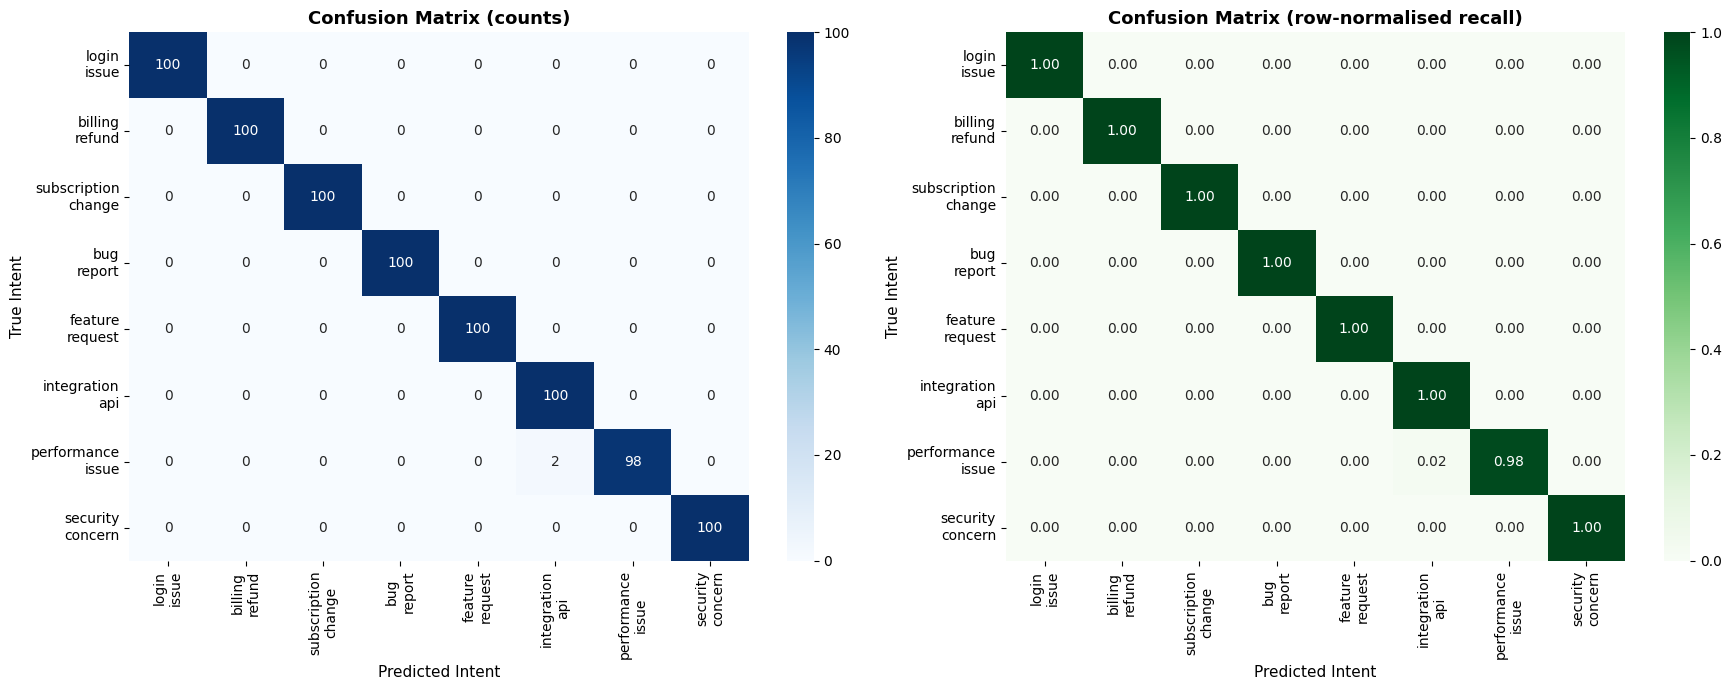

✓ Saved confusion_matrix.png


In [ ]:
# ── Cell 12: Confusion matrix ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

intent_labels = [ID2LABEL[i] for i in range(NUM_LABELS)]
short_labels  = [l.replace('_', '\n') for l in intent_labels]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Intent', fontsize=11)
axes[0].set_xlabel('Predicted Intent', fontsize=11)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=short_labels, yticklabels=short_labels,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (row-normalised recall)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Intent', fontsize=11)
axes[1].set_xlabel('Predicted Intent', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved confusion_matrix.png')

## Cell 13 — Training curves

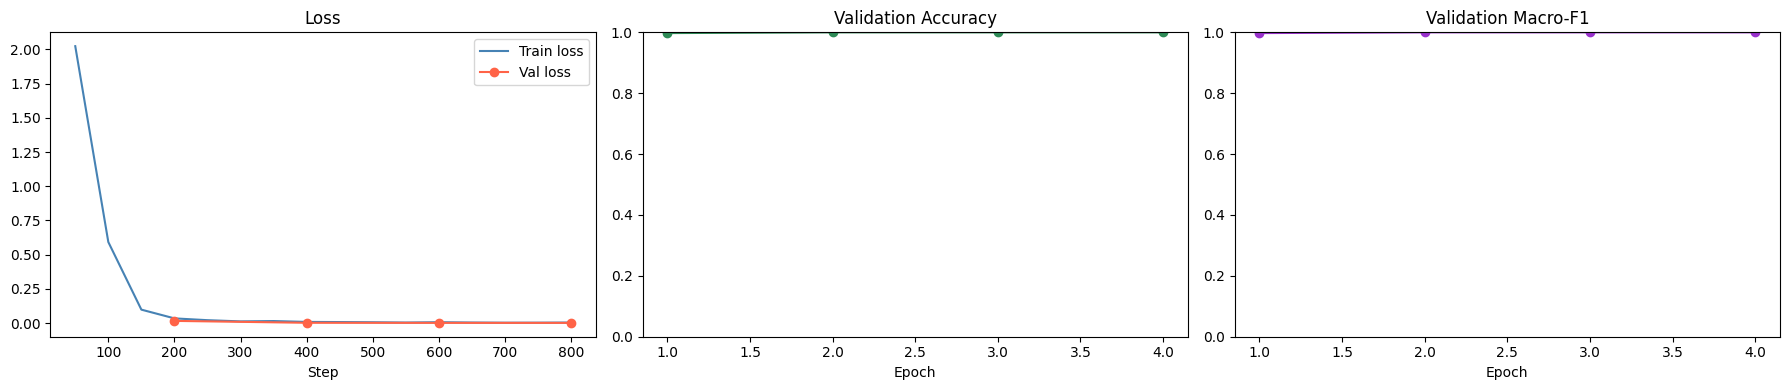

✓ Saved training_curves.png


In [ ]:
# ── Cell 13: Training curves ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_logs = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in log_history if 'eval_loss' in l]

if train_logs and eval_logs:
    train_steps   = [l['step']               for l in train_logs]
    train_losses  = [l['loss']               for l in train_logs]
    eval_epochs   = [l['epoch']              for l in eval_logs]
    eval_losses   = [l['eval_loss']          for l in eval_logs]
    eval_macro_f1 = [l.get('eval_macro_f1', 0) for l in eval_logs]
    eval_acc      = [l.get('eval_accuracy',  0) for l in eval_logs]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(train_steps, train_losses, label='Train loss', color='steelblue')
    axes[0].plot([l['step'] for l in eval_logs], eval_losses, 'o-', label='Val loss', color='tomato')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Step'); axes[0].legend()

    axes[1].plot(eval_epochs, eval_acc, 'o-', color='seagreen')
    axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1)

    axes[2].plot(eval_epochs, eval_macro_f1, 'o-', color='darkorchid')
    axes[2].set_title('Validation Macro-F1'); axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved training_curves.png')
else:
    print('No log history available yet — run after training.')

## Cell 14 — Inference demo

Tests three types of emails to probe generalisation:
1. **Generated** — emails similar to training data style
2. **Handwritten** — natural phrasing written by a human (OOD generalisation check)
3. **Hard / multi-intent** — ambiguous emails mentioning multiple issues (primary-intent decision)

The function also now returns full top-3 probabilities.

In [ ]:
# ── Cell 14: Inference demo ───────────────────────────────────────────────────
import torch, torch.nn.functional as F

def predict_email(text: str, top_k: int = 3) -> dict:
    """
    Classify a raw email string.
    Returns the predicted intent, routed department, confidence, and top-k breakdown.
    """
    model.eval()
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_SEQ_LEN,
        return_tensors='pt',
    ).to(device)

    with torch.no_grad():
        logits = model(**enc).logits

    probs    = F.softmax(logits, dim=-1).squeeze().cpu()
    top_idxs = probs.argsort(descending=True)[:top_k]

    top = []
    for idx in top_idxs:
        intent = ID2LABEL[int(idx)]
        top.append({
            'intent':     intent,
            'department': DEPT_MAP[intent],
            'confidence': round(float(probs[idx]), 4),
        })

    return {
        'predicted_intent': top[0]['intent'],
        'routed_to':        top[0]['department'],
        'confidence':       top[0]['confidence'],
        'top_k':            top,
    }

# ─────────────────────────────────────────────────────────────────────────────
# TYPE 1: Generated-style emails (similar to training distribution)
# ─────────────────────────────────────────────────────────────────────────────
generated_emails = [
    ("Can't log in after password reset",
     "Hi Team, I reset my password yesterday but I still get 'invalid credentials' "     "every time I try to log in. I've tried Chrome and Safari, cleared my cookies. "     "Please help — I have a demo in 2 hours. Thanks, Rachel"),

    ("Unexpected charge on invoice",
     "Hello, We were charged $499 this month but our contract states $299/month for "     "the Professional plan. I'd like a refund for the difference and an explanation. "     "Best, James Martin, CFO"),

    ("Webhook not firing on order.completed event",
     "Hey, our webhook endpoint is registered and returns 200 but we're not receiving "     "payloads for the order.completed event. Other event types work fine. API version: v3.1. "     "Cheers, Wei Chen"),
]

# ─────────────────────────────────────────────────────────────────────────────
# TYPE 2: Handwritten emails — natural human phrasing (OOD test)
# ─────────────────────────────────────────────────────────────────────────────
handwritten_emails = [
    ("Slow dashboard",
     "hey the dashboard is like super slow since yesterday's update, takes forever to load, "     "my whole team is blocked. we're on enterprise with like 2000 records or something"),

    ("Suspicious login",
     "got an alert my account was accessed from singapore. i live in ohio. "     "please lock it now and tell me what happened — Sofia"),

    ("Upgrade question",
     "hi, i want to move from the starter plan to pro but i need to know "     "if i can keep my existing data and how long the migration takes. thanks"),
]

# ─────────────────────────────────────────────────────────────────────────────
# TYPE 3: Hard / multi-intent emails — model must pick the PRIMARY intent
# ─────────────────────────────────────────────────────────────────────────────
hard_emails = [
    ("[HARD] Billing + login issue",
     "I upgraded to Pro yesterday. I was charged twice on my card AND I still "     "can't log in. Not sure which problem to solve first but both are urgent."),

    ("[HARD] Performance + data loss worry",
     "The app has been incredibly slow all day and when I finally got in I noticed "     "some of my reports from last week seem to be missing. Is there an outage? "     "Are my reports gone? This is for a client presentation tomorrow."),

    ("[HARD] Security + access",
     "Someone from an unknown location accessed my account. I changed my password "     "immediately but I still can't log back in — it says my account is locked. "     "How do I get back in and make sure this doesn't happen again?"),
]

# ─────────────────────────────────────────────────────────────────────────────
# Run all three test types
# ─────────────────────────────────────────────────────────────────────────────
def run_demo(email_list, section_title):
    print(f'\n{"─" * 65}')
    print(f'  {section_title}')
    print(f'{"─" * 65}')
    for subject, body in email_list:
        text = f"Subject: {subject}\\n\\n{body}"
        result = predict_email(text.strip())
        print(f'\n📧  {subject}')
        print(f'   → Intent    : {result["predicted_intent"]}  ({result["confidence"]*100:.1f}%)')
        print(f'   → Route to  : {result["routed_to"]}')
        print(f'   → Top-3     : ' +
              ', '.join(f'{t["intent"]} ({t["confidence"]*100:.0f}%)' for t in result['top_k']))

print('\n' + '=' * 65)
print('  INFERENCE DEMO')
print('=' * 65)
run_demo(generated_emails,  '1 / Generated-style emails (similar to training data)')
run_demo(handwritten_emails,'2 / Handwritten emails (natural human phrasing — OOD test)')
run_demo(hard_emails,       '3 / Hard multi-intent emails (primary-intent decision)')


  INFERENCE DEMO

─────────────────────────────────────────────────────────────────
  1 / Generated-style emails (similar to training data)
─────────────────────────────────────────────────────────────────

📧  Can't log in after password reset
   → Intent    : login_issue  (99.8%)
   → Route to  : Technical Support
   → Top-3     : login_issue (100%), integration_api (0%), subscription_change (0%)

📧  Unexpected charge on invoice
   → Intent    : billing_refund  (99.8%)
   → Route to  : Billing
   → Top-3     : billing_refund (100%), integration_api (0%), performance_issue (0%)

📧  Webhook not firing on order.completed event
   → Intent    : integration_api  (99.8%)
   → Route to  : Developer Support
   → Top-3     : integration_api (100%), billing_refund (0%), login_issue (0%)

─────────────────────────────────────────────────────────────────
  2 / Handwritten emails (natural human phrasing — OOD test)
─────────────────────────────────────────────────────────────────

📧  Slow dashboa

## Cell 15 — Unseen holdout evaluation

> **The most important evaluation step.**

If `holdout.jsonl` was uploaded in Cell 2, evaluate the model on it now.
This file should contain emails that were:
- Generated with a **different prompt or temperature**, or
- **Written by hand** — which is even better.

If you don't have a holdout file yet, the cell explains how to create one.
The key principle: this set must have been completely excluded from all training and validation.

In [ ]:
# ── Cell 15: Unseen holdout evaluation ───────────────────────────────────────
# NEW: evaluates the model on a completely independent set of emails.
#
# Why this matters:
#   All train/val/test splits come from the same generator distribution.
#   The model may have learned the generator's writing style rather than
#   genuine intent signals. A holdout from a different source gives much
#   stronger evidence that it learned the actual task.
#
# How to create a holdout set if you don't have one:
#   Option A (best):  Write 150–200 emails yourself, one per intent.
#                     Natural, varied phrasing — typos, different tones, short/long.
#   Option B (good):  Re-run your generator with a different system prompt or
#                     temperature and never include those emails in training.
#
# File format: same JSONL format as test.jsonl
#   {"text": "...", "intent": "login_issue", "department": "Technical Support", "label": 0}

if not HAS_HOLDOUT:
    print('ℹ️  No holdout.jsonl was uploaded in Cell 2 — skipping this evaluation.')
    print()
    print('To create a holdout set:')
    print('  1. Write or generate ~200 emails covering all 8 intents')
    print('  2. Format them as JSONL (same schema as test.jsonl)')
    print('  3. Re-run the notebook from Cell 2 with holdout.jsonl included')
    print()
    print('Recommended: at least 15–20 emails per class, with varied phrasing.')
else:
    import numpy as np
    import torch, torch.nn.functional as F
    from sklearn.metrics import accuracy_score, f1_score, classification_report
    import pandas as pd, json

    print('Running evaluation on unseen holdout set...\n')

    # Tokenise holdout
    holdout_tok = tokenised['holdout'] if 'holdout' in tokenised else None
    if holdout_tok is None:
        print('⚠️  Holdout set was not tokenised. Re-run from Cell 5.')
    else:
        holdout_output = trainer.predict(holdout_tok)

        h_logits = holdout_output.predictions
        h_pred   = np.argmax(h_logits, axis=-1)
        h_true   = holdout_output.label_ids
        h_probs  = F.softmax(torch.tensor(h_logits), dim=-1).numpy()
        h_conf   = h_probs[np.arange(len(h_pred)), h_pred]

        h_acc      = accuracy_score(h_true, h_pred)
        h_macro_f1 = f1_score(h_true, h_pred, average='macro', zero_division=0)

        print('=' * 55)
        print('HOLDOUT SET RESULTS  (completely unseen)')
        print('=' * 55)
        print(f'  Accuracy  : {h_acc:.4f}  ({h_acc*100:.2f}%)')
        print(f'  Macro F1  : {h_macro_f1:.4f}')
        print(f'  N samples : {len(h_true)}')

        print('\nPer-class report:')
        print(classification_report(
            h_true, h_pred,
            target_names=[ID2LABEL[i] for i in range(NUM_LABELS)],
            zero_division=0,
        ))

        # Compare to in-distribution test set
        print('── Holdout vs test-set performance ──')
        compare_h = pd.DataFrame([
            {'Split': 'Test (in-distribution)',    'Accuracy': f'{acc:.4f}', 'Macro F1': f'{macro_f1:.4f}'},
            {'Split': 'Holdout (unseen)',           'Accuracy': f'{h_acc:.4f}', 'Macro F1': f'{h_macro_f1:.4f}'},
        ])
        print(compare_h.to_string(index=False))

        drop_f1 = (macro_f1 - h_macro_f1) * 100
        if drop_f1 > 10:
            print(f'\n⚠️  Performance drop of {drop_f1:.1f}pp macro-F1 on holdout — the model may')
            print(f'    have partially learned the generator\'s style. Consider:')
            print(f'    • Adding more varied holdout examples to training data')
            print(f'    • Using a different generator prompt for the holdout')
        elif drop_f1 > 0:
            print(f'\n✓ Modest drop of {drop_f1:.1f}pp on holdout — expected and acceptable.')
        else:
            print(f'\n✓ Holdout performance is on par with test set — strong generalisation signal!')

## Cell 16 — Save model

In [ ]:
# ── Cell 16: Save model ───────────────────────────────────────────────────────
import os, json, shutil

SAVE_DIR = './email-intent-classifier'
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
shutil.copy('label_metadata.json', os.path.join(SAVE_DIR, 'label_metadata.json'))

# Load baseline comparison if it exists
try:
    with open('baseline_comparison.json') as f:
        bc = json.load(f)
    baseline_row = f'| TF-IDF + Logistic Regression | {bc["tfidf_lr"]["accuracy"]:.4f} | {bc["tfidf_lr"]["macro_f1"]:.4f} |'
    transformer_row = f'| DistilRoBERTa (fine-tuned)    | {bc["distilroberta"]["accuracy"]:.4f} | {bc["distilroberta"]["macro_f1"]:.4f} |'
except FileNotFoundError:
    baseline_row = '| TF-IDF + Logistic Regression | — | — |'
    transformer_row = f'| DistilRoBERTa (fine-tuned) | {acc:.4f} | {macro_f1:.4f} |'

model_card = f"""# Email Intent Classifier

Fine-tuned `distilroberta-base` for SaaS customer-support email intent classification.

## Labels

| ID | Intent | Department |
|----|--------|------------|
""" + '\n'.join(
    f'| {i} | `{ID2LABEL[i]}` | {DEPT_MAP[ID2LABEL[i]]} |'
    for i in range(NUM_LABELS)
) + f"""

## Model Comparison

| Model | Accuracy | Macro F1 |
|-------|----------|----------|
{baseline_row}
{transformer_row}

## Training

- Base model  : `distilroberta-base`
- Dataset     : 8,000 training / 1,000 validation / 1,000 test (synthetic)
- Max seq len : {MAX_SEQ_LEN}
- Max epochs  : {NUM_EPOCHS} (Early Stopping patience=2)
- Batch size  : {TRAIN_BATCH_SIZE}
- LR          : {LEARNING_RATE}

## Inference

```python
from transformers import pipeline
import json

meta = json.load(open('label_metadata.json'))
clf  = pipeline('text-classification', model='./email-intent-classifier', top_k=3)

results = clf(email_text)
top     = results[0]   # highest-confidence prediction
intent  = top['label']
dept    = meta['intent_metadata'][intent]['department']
conf    = top['score']
```
"""
with open(os.path.join(SAVE_DIR, 'README.md'), 'w') as f:
    f.write(model_card)

files_saved = os.listdir(SAVE_DIR)
print(f'✓ Model saved to {SAVE_DIR}/')
print(f'  Files: {files_saved}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved to ./email-intent-classifier/
  Files: ['model.safetensors', 'tokenizer_config.json', 'config.json', 'tokenizer.json', 'README.md', 'label_metadata.json']


## Cell 17 — Production inference snippet (`email_classifier.py`)

In [ ]:
# ── Cell 17: Production inference snippet ─────────────────────────────────────
# FIXES vs original Cell 16:
#   1. device defaults to -1 (CPU); change to 0 for GPU deployment
#   2. top_k=3 returns top-3 predictions, not just the single best
#   3. Returns structured dict with intent, department, confidence, AND top-3

PRODUCTION_SNIPPET = '''#!/usr/bin/env python3
"""
email_classifier.py — drop into your routing service.
Unzip email-intent-classifier.zip and set MODEL_PATH to the folder.
"""
import json
from transformers import pipeline

MODEL_PATH = "./email-intent-classifier"   # path to unzipped model folder

# ── Load once at startup ──────────────────────────────────────────────────────
# device=-1 → CPU (change to device=0 for GPU deployment)
_clf  = pipeline("text-classification", model=MODEL_PATH, device=-1, top_k=3)
_meta = json.load(open(f"{MODEL_PATH}/label_metadata.json"))


def classify_email(subject: str, body: str) -> dict:
    """
    Classify a support email.

    Returns:
        {
            "intent":     str,          # e.g. "login_issue"
            "department": str,          # e.g. "Technical Support"
            "confidence": float,        # 0–1, confidence in top prediction
            "top3": [                   # ranked by confidence
                {"intent": str, "department": str, "confidence": float},
                ...
            ]
        }
    """
    text    = f"Subject: {subject}\\n\\n{body}"
    results = _clf(text, truncation=True, max_length=256)[0]   # list of 3 dicts

    top3 = [
        {
            "intent":     r["label"],
            "department": _meta["intent_metadata"][r["label"]]["department"],
            "confidence": round(r["score"], 4),
        }
        for r in results
    ]

    return {
        "intent":     top3[0]["intent"],
        "department": top3[0]["department"],
        "confidence": top3[0]["confidence"],
        "top3":       top3,
    }


# ── Example usage ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    out = classify_email(
        subject="Can\'t log in after SSO update",
        body="Hi, since this morning our whole team can\'t access the portal...",
    )
    import json as _json
    print(_json.dumps(out, indent=2))
    # Expected output:
    # {
    #   "intent": "login_issue",
    #   "department": "Technical Support",
    #   "confidence": 0.9871,
    #   "top3": [
    #     {"intent": "login_issue", "department": "Technical Support", "confidence": 0.9871},
    #     {"intent": "account_management", "department": "Customer Success", "confidence": 0.0089},
    #     {"intent": "technical_bug", "department": "Engineering", "confidence": 0.0031}
    #   ]
    # }
'''

print(PRODUCTION_SNIPPET)

with open('email_classifier.py', 'w') as f:
    f.write(PRODUCTION_SNIPPET.strip())
print('\n✓ Saved email_classifier.py')

## Cell 18 — Download everything

In [ ]:
# ── Cell 18: Download model + artefacts ──────────────────────────────────────
import shutil, os
from google.colab import files

# Zip the model
ZIP_PATH = 'email-intent-classifier.zip'
shutil.make_archive('email-intent-classifier', 'zip', '.', 'email-intent-classifier')
size_mb = os.path.getsize(ZIP_PATH) / 1e6
print(f'✓ Zipped model: {ZIP_PATH} ({size_mb:.0f} MB)')

# Download model zip
files.download(ZIP_PATH)

# Download plots + analysis artefacts
artefacts = [
    'confusion_matrix.png',
    'training_curves.png',
    'predictions.json',
    'baseline_comparison.json',
    'email_classifier.py',
]
for artefact in artefacts:
    if os.path.exists(artefact):
        files.download(artefact)
        print(f'  Downloaded {artefact}')
    else:
        print(f'  ⏭  {artefact} not found (cell may not have run yet)')

✓ Zipped model: email-intent-classifier.zip (306 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded predictions.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded baseline_comparison.json
  ⏭  email_classifier.py not found (cell may not have run yet)
